In [1]:
#Import Packages
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import functools  

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import log_loss

import torch
from torch import nn
from torch.utils.data import DataLoader
from pathlib import Path

import shap
import xgboost

current_season = 2025

In [2]:
# Read in data
data_path = Path('data')

# Men's
m_massey = pd.read_csv(f'{data_path}/MMasseyOrdinals.csv')
m_teams = pd.read_csv(f'{data_path}/MTeams.csv')
m_reg_season_results = pd.read_csv(f'{data_path}/MRegularSeasonCompactResults.csv')
m_reg_season_stats = pd.read_csv(f'{data_path}/MRegularSeasonDetailedResults.csv')
m_tourney_results = pd.read_csv(f'{data_path}/MNCAATourneyCompactResults.csv')
m_conf_results = pd.read_csv(f'{data_path}/MConferenceTourneyGames.csv')
rpi = pd.read_csv(f'{data_path}/{current_season}MRanks.csv')
m_seeds = pd.read_csv(f'{data_path}/MNCAATourneySeeds.csv')

# Women's
w_teams = pd.read_csv(f'{data_path}/WTeams.csv')
w_reg_season_results = pd.read_csv(f'{data_path}/WRegularSeasonCompactResults.csv')
w_reg_season_stats = pd.read_csv(f'{data_path}/WRegularSeasonDetailedResults.csv')
w_tourney_results = pd.read_csv(f'{data_path}/WNCAATourneyCompactResults.csv')
w_seeds = pd.read_csv(f'{data_path}/WNCAATourneySeeds.csv')
w_ranks = pd.read_csv(f'{data_path}/w2025_ap_ranks.csv')

sample_submission = pd.read_csv(f'{data_path}/SampleSubmissionStage2.csv')

## Point Differential

In [3]:
def create_point_differential(df):
    df['WTeamPointDiff'] = df['WScore'] - df['LScore']
    df['LTeamPointDiff'] = df['WTeamPointDiff'] * -1

    win_point_diff = (
        df.groupby(['Season','WTeamID'], as_index=False)['WTeamPointDiff'].sum()
    )
    loss_point_diff = (
        df.groupby(['Season','LTeamID'], as_index=False)['LTeamPointDiff'].sum()
    )
    merged_point_diff = (
        win_point_diff
        .merge(loss_point_diff, how ='left', left_on=['Season', 'WTeamID'], right_on=['Season', 'LTeamID'])
    )
    merged_point_diff['point_diff'] = merged_point_diff['WTeamPointDiff'] + merged_point_diff['LTeamPointDiff']
    return merged_point_diff
    
m_point_diff = create_point_differential(m_reg_season_stats)
w_point_diff = create_point_differential(w_reg_season_stats)

In [4]:
def create_reg_season_record(df):
    #Create 4 dataframes - wins, losses, home wins, nuetral wins
    wins_df = df.groupby(['WTeamID','Season'], as_index=False)['WScore'].count()
    loss_df = df.groupby(['LTeamID','Season'], as_index=False)['LScore'].count()
    home_wins_df = df[df.WLoc == 'H'].groupby(['WTeamID','Season'], 
                                              as_index=False)['WScore'].count()
    
    #Merge the dataframes
    reg_season_record_df = (
        wins_df
        .merge(loss_df, how="outer", left_on =['WTeamID','Season'], right_on = ['LTeamID','Season'])
    )
    reg_season_record_df = (
        reg_season_record_df
        .merge(home_wins_df, how="outer",left_on =['WTeamID','Season'], right_on = ['WTeamID','Season'])
    )
    #Rename columns
    reg_season_record_df.columns = ['TeamID','Season','Wins','LTeamID','Losses','Home_wins']

    #Fill in NA columns with 0 and change the column data type to an integer
    reg_season_record_df['TeamID'] = reg_season_record_df['TeamID'].fillna(reg_season_record_df['LTeamID']).astype(int)
    reg_season_record_df[['Wins','LTeamID','Losses','Home_wins']] = \
        reg_season_record_df[['Wins','LTeamID','Losses','Home_wins']].fillna(0).astype(int)

    #The LTeamID column is not needed so drop it
    reg_season_record_df = reg_season_record_df.drop('LTeamID', axis = 1)
    
    reg_season_record_df = reg_season_record_df.loc[reg_season_record_df.Season >= 2003]
    
    return reg_season_record_df
    
m_reg_season_record = create_reg_season_record(m_reg_season_results)
w_reg_season_record = create_reg_season_record(w_reg_season_results)

In [5]:
system_lst = ['POM','WLK', 'MOR']
rank_day_lst = [126,127,128]
# rank_day_lst = [126, 127, 128, 133]
def assign_tm_ranks(system_lst, day_of_rank):
    ranking_lst = []
    #Subset data for Ranking System and the day of rank
    for system in system_lst:
        tm_rank = (
            m_massey.loc[(m_massey.SystemName == system) & (m_massey.RankingDayNum.isin(day_of_rank))
                        ][['TeamID','Season','OrdinalRank']]
        )
        tm_rank.rename(columns={'OrdinalRank': system}, inplace=True)
        
        ranking_lst.append(tm_rank)
    
    full_tm_rank = functools.reduce(lambda x, y: pd.merge(x, y, how='left', on=['TeamID','Season']), ranking_lst)
    
    reg_season_rank_df = m_reg_season_record.merge(
        full_tm_rank, how='left', on=['TeamID','Season']
    )
    return reg_season_rank_df

m_reg_season_rank = assign_tm_ranks(system_lst, rank_day_lst)

## Top Wins

In [6]:
# Merge the RPI df with the regular season results df
m_top_wins = m_reg_season_results.merge(
    rpi,
    how = 'inner',
    left_on = ['Season','LTeamID'], 
    right_on = ['Season', 'TeamID']
)
#Create columns to mark the category of ranking that the losing opponent fell into
m_top_wins['Wins1_25'] = m_top_wins['RPI'].apply(lambda x: 1 if x <=25 else 0)
m_top_wins['Wins26_50'] = m_top_wins['RPI'].apply(lambda x: 1 if x > 25 and x<=50 else 0)
m_top_wins['Wins51_100'] = m_top_wins['RPI'].apply(lambda x: 1 if x <=100 and x > 50 else 0)
m_top_wins['Wins101_200'] = m_top_wins['RPI'].apply(lambda x: 1 if x <=200 and x > 100 else 0)

# Aggregate the sum of wins by opponent ranking category
m_top_wins = m_top_wins.groupby(
    ['Season','WTeamID'], as_index=False
)[['Wins1_25','Wins26_50','Wins51_100','Wins101_200']].sum()

#Rename the Team Column
m_top_wins.rename(columns={'WTeamID':'TeamID'}, inplace=True)

In [7]:
def create_own_stats(df):
    # Subset the columns of the regular season stats dataframe for the columns we want based on the games the team won
    own_wins_stats_df = df[['Season','WTeamID','WScore','WFGM','WFGA','WFGM3','WFGA3',
                            'WFTM','WFTA','WOR','WDR','WAst','WTO','WStl','WBlk','WPF']]
    
    # Rename the columns
    own_wins_stats_df.columns = ['Season','TeamID','O_Score','O_FGM','O_FGA','O_FGM3','O_FGA3','O_FTM','O_FTA',
                                 'O_OR','O_DR','O_Ast','O_TO','O_Stl','O_Blk','O_PF']
    
    # Subset the columns of the regular season stats dataframe for the columns we want based on the games the team loss
    own_loss_stats_df = df[['Season','LTeamID','LScore','LFGM','LFGA','LFGM3',
                            'LFGA3','LFTM','LFTA','LOR','LDR','LAst','LTO','LStl','LBlk','LPF']]
    
    # Rename the columns so that they match the columns in the wins df
    own_loss_stats_df.columns = ['Season','TeamID','O_Score','O_FGM','O_FGA','O_FGM3','O_FGA3','O_FTM','O_FTA',
                                 'O_OR','O_DR','O_Ast','O_TO','O_Stl','O_Blk','O_PF']
    
    # Append the loss df to the win df
    own_stats_df = pd.concat([own_wins_stats_df, own_loss_stats_df], axis=0)
    
    # Take the average of the stats, grouped by season and team
    own_stats_agg = own_stats_df.groupby(['Season','TeamID'], as_index=False).mean()
    
    return own_stats_agg
    
m_own_stats_agg = create_own_stats(m_reg_season_stats)
w_own_stats_agg = create_own_stats(w_reg_season_stats)

In [8]:
def create_opp_stats(df):
    #Subset the columns of the regular season stats dataframe for the columns we want based on the games the team won, but taking the stats of the losing team
    opp_wins_stats_df = df[['Season','WTeamID','LScore','LFGM','LFGA','LFGM3',\
                                             'LFGA3','LFTM','LFTA','LOR','LDR','LAst','LTO','LStl','LBlk','LPF']]

    #Rename the columns
    opp_wins_stats_df.columns = ['Season','TeamID','D_Score','D_FGM','D_FGA','D_FGM3','D_FGA3','D_FTM','D_FTA',\
                                'D_OR','D_DR','D_Ast','D_TO','D_Stl','D_Blk','D_PF']

    #Subset the columns of the regular season stats dataframe for the columns we want based on the games the team loss, but taking the stats of the winning team
    opp_loss_stats_df = df[['Season','LTeamID','WScore','WFGM','WFGA','WFGM3',\
                                             'WFGA3','WFTM','WFTA','WOR','WDR','WAst','WTO','WStl','WBlk','WPF']]

    #Rename the columns so that they match the columns in the wins df
    opp_loss_stats_df.columns = ['Season','TeamID','D_Score','D_FGM','D_FGA','D_FGM3','D_FGA3','D_FTM','D_FTA',\
                                'D_OR','D_DR','D_Ast','D_TO','D_Stl','D_Blk','D_PF']

    #Append the loss df to the win df
    opp_stats_df = pd.concat([opp_wins_stats_df, opp_loss_stats_df], axis=0)

    #Take the average of the stats, grouped by season and team
    opp_stats_agg = opp_stats_df.groupby(['Season','TeamID'], as_index=False).mean()
    
    return opp_stats_agg

m_opp_stats_agg = create_opp_stats(m_reg_season_stats)
w_opp_stats_agg = create_opp_stats(w_reg_season_stats)

In [9]:
# Merge the average personal team stats with the average opponent team stats

# Men's
m_reg_season_stats_agg = m_own_stats_agg.merge(
    m_opp_stats_agg, how='left', left_on=['Season','TeamID'], right_on=['Season','TeamID']
)
# Women's
w_reg_season_stats_agg = w_own_stats_agg.merge(
    w_opp_stats_agg, how='left', left_on=['Season','TeamID'], right_on=['Season','TeamID']
)

In [10]:
def create_team_resume(df, gender='m'):
    if gender == 'm':
        #Merging the ranking dataframe with the season stats dataframe
        resume_df = df.merge(
            m_reg_season_rank, how = 'left', left_on=['Season','TeamID'], right_on=['Season','TeamID']
        )
        # Merging the Quality Wins dataframe with the previous two
        resume_df = resume_df.merge(m_top_wins, how ='left', left_on=['Season','TeamID'], right_on=['Season','TeamID'])

        # Filling any NA fields with 0, because some teams did not have quality wins
        resume_df[['Wins1_25', 'Wins26_50', 'Wins51_100', 'Wins101_200']] = (
            resume_df[['Wins1_25', 'Wins26_50', 'Wins51_100', 'Wins101_200']]
            .fillna(0)
            .astype(int)
        )

        # Subsetting the data to after the 2003 season because that is when they two ranking systems we are using began
        resume_df = resume_df.loc[(resume_df['Season'] > 2003) & (resume_df['Season'] <= current_season)]

        # Merging the Strength of Schedule dataframe with the previous 3
        resume_df = resume_df.merge(
            rpi, how = 'left', left_on = ['Season','TeamID'], right_on = ['Season','TeamID']
        ).drop(['Team'], axis = 1)

        # Filling in any missing data from the Strength of Schedule dataframe with the worst rankings and converting them to integers
        resume_df['Power'] = resume_df['Power'].fillna(0)
        resume_df = resume_df.fillna(300)
        # resume_df = resume_df.fillna(int(resume_df.loc[pd.isnull(resume_df.RPI)].POM.mean())).astype(int)
        return resume_df
    
    elif gender == 'w':
        resume_df = (
            df
            .merge(w_ranks, how='left', on=['Season', 'TeamID'])
        )
        
        resume_df['rk'] = resume_df['rk'].fillna(100).astype(int)
        resume_df[['pts', 'first_place_votes']] = resume_df[['pts', 'first_place_votes']].fillna(0).astype(int)
        
        return resume_df.drop('Team', axis=1)

    return df

m_resume_df = create_team_resume(m_reg_season_stats_agg)
w_resume_df = create_team_resume(w_reg_season_stats_agg, gender='w')

In [11]:
# Create function to determine the team with the lower ID
def lower_id_func(row):
    if row['WTeamID'] < row['LTeamID']:
        return int(row['WTeamID'])
    else:
        return int(row['LTeamID'])

#Create function to determine whether or not the lower ID team won
def lower_won_func(row):
    if row['WTeamID'] < row['LTeamID']:
        return 1
    else:
        return 0

In [12]:
def tourney_result_transform(resume_df, tourney_results_df):
    #Create a column with the lower ID team as team_1
    tourney_results_df['team_1'] = tourney_results_df.apply(lower_id_func, axis = 1)

    #Create a column with the higher ID team as team_2
    tourney_results_df['team_2'] = tourney_results_df.apply(lambda x: int(x['LTeamID']) if int(x['WTeamID']) == x['team_1']\
                                                            else x['WTeamID'], axis = 1)

    #Create a column that shows whether or not team_1 won
    tourney_results_df['Lower_Won'] = tourney_results_df.apply(lower_won_func, axis = 1)

    tourney_results_df = tourney_results_df[['Season','team_1','team_2','Lower_Won']]

    #Merge in resume data with the tournament results data with team_1 as the key
    df = tourney_results_df.merge(resume_df, how='inner', left_on=['Season','team_1'], right_on=['Season','TeamID'])

    #Drop the TeamID column
    df = df.drop('TeamID', axis=1)

    #Merge in resume data with the tournament results data with team_2 as the key

    df = df.merge(resume_df, how='inner', left_on=['Season','team_2'], right_on=['Season','TeamID'])

    #Drop the TeamID column
    df = df.drop('TeamID', axis = 1)

    #Rename the columns to get rid of the suffixes using list comprehension
    column_lst = [i.replace('_x','_team_1') for i in list(df.columns)]
    column_lst = [i.replace('_y','_team_2') for i in column_lst]

    df.columns = column_lst
    
    return df
    
m_tourney_transform = tourney_result_transform(m_resume_df, m_tourney_results)
w_tourney_transform = tourney_result_transform(w_resume_df, w_tourney_results)

In [13]:
def add_seed_info(seed_df, tourney_df):
    
    seed_df = seed_df.copy()
    # Extract the seed number (withouth the region letters) from the seed column
    seed_df['Seed'] = seed_df['Seed'].apply(lambda x: int(x[1:]) if len(x) == 3 else int(x[1:3]))
    
    # Merge the seeds dataframe with the tournament results with team_1 as the key
    tourney_results_df = tourney_df.merge(
        seed_df, how = 'left', left_on = ['Season','team_1'], right_on = ['Season','TeamID']
    ).drop('TeamID', axis = 1).rename(columns={'Seed':'Seed_team_1'})
    
    # Merge the seeds dataframe with the tournament results with team_2 as the key
    tourney_results_df = tourney_results_df.merge(
        seed_df, how = 'left', left_on = ['Season','team_2'], right_on = ['Season','TeamID']
    ).drop('TeamID', axis = 1).rename(columns={'Seed':'Seed_team_2'})
    
    return tourney_results_df

m_tourney_seeds = add_seed_info(m_seeds, m_tourney_transform)
w_tourney_seeds = add_seed_info(w_seeds, w_tourney_transform)

In [14]:
# Create a column with the lower ID team as team_1
m_conf_results['team_1'] = m_conf_results.apply(lower_id_func, axis =1)

# Create a column with the higher ID team as team_2
m_conf_results['team_2'] = m_conf_results.apply(
    lambda x: int(x['LTeamID']) if int(x['WTeamID']) == x['team_1'] else x['WTeamID'], axis = 1
)

# Create a column that shows whether or not team_1 won
m_conf_results['Lower_Won'] = m_conf_results.apply(lower_won_func, axis = 1)

m_conf_results = m_conf_results[['Season','team_1','team_2','Lower_Won']]

# Merge in resume data with the conference tournament results data with team_1 as the key
m_conf_results = m_conf_results.merge(
    m_resume_df, how = 'inner', left_on = ['Season','team_1'], right_on = ['Season','TeamID']
).drop('TeamID', axis =1)

# Merge in resume data with the conference tournament results data with team_2 as the key
m_conf_results = m_conf_results.merge(
    m_resume_df, how = 'inner', left_on = ['Season','team_2'],right_on = ['Season','TeamID']
).drop('TeamID', axis =1)

# Rename the columns to get rid of the suffixes using list comprehension
column_lst = [i.replace('_x','_team_1') for i in list(m_conf_results.columns)]
column_lst = [i.replace('_y','_team_2') for i in column_lst]

m_conf_results.columns = column_lst

# Merge the seeds dataframe with the conference tournament results with team_1 as the key
m_conf_results = m_conf_results.merge(
    m_seeds, how = 'inner', left_on = ['Season','team_1'], right_on = ['Season','TeamID']
).drop('TeamID', axis = 1).rename(columns={'Seed':'Seed_team_1'})

# Merge the seeds dataframe with the conference tournament results with team_2 as the key
m_conf_results = m_conf_results.merge(
    m_seeds, how = 'inner', left_on = ['Season','team_2'], right_on = ['Season','TeamID']
).drop('TeamID', axis = 1).rename(columns={'Seed':'Seed_team_2'})


m_conf_results['Seed_team_1'] = m_conf_results['Seed_team_1'].apply(lambda x: int(x[1:]) if len(x) == 3 else int(x[1:3]))
m_conf_results['Seed_team_2'] = m_conf_results['Seed_team_2'].apply(lambda x: int(x[1:]) if len(x) == 3 else int(x[1:3]))

# Append the conference tournament games to the NCAA tournament games
m_tourney_seeds = pd.concat([m_tourney_seeds, m_conf_results], axis=0)

In [15]:
m_tourney_seeds["SoS_x_RPI_team_1"] = m_tourney_seeds["SoS_team_1"] * m_tourney_seeds["RPI_team_1"]
m_tourney_seeds["SoS_x_RPI_team_2"] = m_tourney_seeds["SoS_team_2"] * m_tourney_seeds["RPI_team_2"]

In [16]:
def create_resume_comparison(df):
    # Subset the fields that are not metrics
    resume_comparison_df = df[['Season','team_1','team_2','Lower_Won', 'Seed_team_1', 'Seed_team_2']]
    
    metric_lst = [x[0:x.find('_team_1')] for x in df.columns if ('_team_1' in x)]
    
    # For each metric, calculate the difference and add it as a field to the resume comparison df
    for metric in metric_lst:
        resume_comparison_df[metric + '_diff'] = df[metric + '_team_2'] - df[metric + '_team_1']
        
    return resume_comparison_df.reset_index(drop=True)

m_resume_comparison = create_resume_comparison(m_tourney_seeds)
w_resume_comparison = create_resume_comparison(w_tourney_seeds)

# # Manually adjust Virginia loss to UMBC Outlier
# m_resume_comparison['Lower_Won'] = np.where(m_resume_comparison.team_1 == 1420, 0, m_resume_comparison['Lower_Won'])

# # Manually adjust Purdue loss to FDU
# m_resume_comparison['Lower_Won'] = np.where((m_resume_comparison.team_2 == 1345) & (m_resume_comparison.team_1 == 1192), 0, m_resume_comparison['Lower_Won'])

# Modeling

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error
from sklearn.metrics import brier_score_loss

def training(resume_comparison_df, current_season=current_season):
    train_df = (
        resume_comparison_df
        .query(f"Season < {current_season}")
    )
    X = train_df.drop(['Season','team_1','team_2','Lower_Won', 'Seed_team_1', 'Seed_team_2'], axis = 1)
    y = train_df.Lower_Won
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42)
    
    # Random Forest
    rf = RandomForestClassifier(n_estimators=500, max_depth=8, min_samples_split=3, criterion='log_loss')
    rf.fit(X_train, y_train)
    rf_preds = rf.predict_proba(X_test)[:, -1]
    rf_brier = round(brier_score_loss(y_test, rf_preds), 3)
    
    # XGBoost
    xgb_model = xgboost.XGBClassifier(n_estimators=350, eta=0.01, max_depth=3)
    xgb_model.fit(X_train, y_train)
    xgb_preds = xgb_model.predict_proba(X_test)[:, -1]
    xgb_brier = round(brier_score_loss(y_test, xgb_preds), 3)
    
    print(f'RF: {rf_brier} || XGB: {xgb_brier}')
    
    return rf, xgb_model, X_train

m_rf_model, m_xgb_model, m_X_train = training(m_resume_comparison)
w_rf_model, w_xgb_model, w_X_train = training(w_resume_comparison)

RF: 0.198 || XGB: 0.195
RF: 0.138 || XGB: 0.137


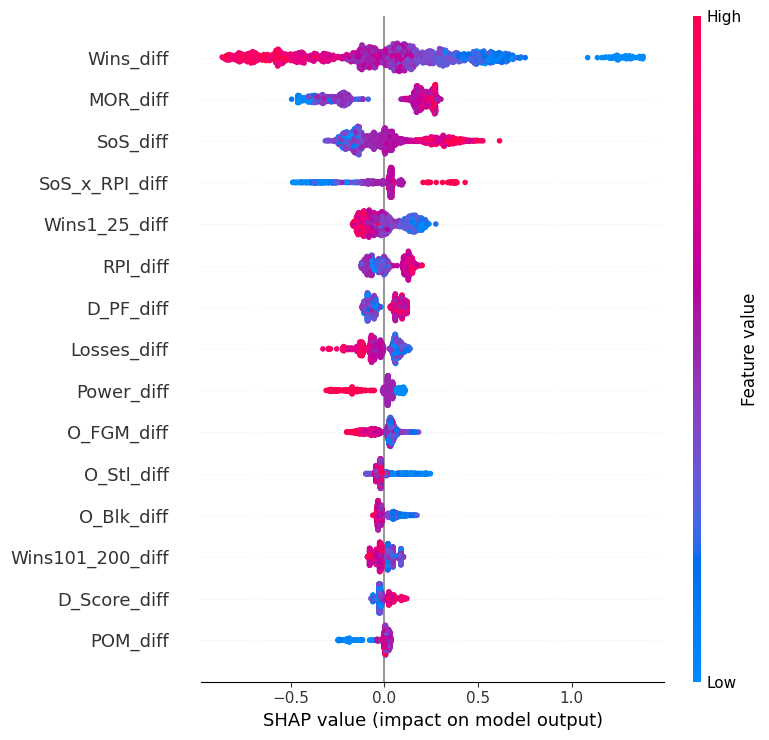

In [18]:
explainer = shap.TreeExplainer(m_xgb_model)
shap_values_train = explainer.shap_values(m_X_train)
shap.summary_plot(shap_values_train, m_X_train, max_display=15)

# Submission

In [20]:
#From the Sample Submission File, split out the year from the ID column
year = sample_submission.ID.str.split('_').apply(lambda x: x[0]).astype(int)

#Extract the first team
team_1 = sample_submission.ID.str.split('_').apply(lambda x: x[1]).astype(int)

#Extract the second team
team_2 = sample_submission.ID.str.split('_').apply(lambda x: x[2]).astype(int)

#Put the 3 series in a data frame
new_sample_submission_df = pd.DataFrame(
    {"ID": sample_submission.ID, 
     "year": year,
     "team_1": team_1,
     "team_2": team_2
    }
)

m_submission_df = new_sample_submission_df.query("team_1 < 3000")
w_submission_df = new_sample_submission_df.query("team_1 > 3000")

In [21]:
def prepare_submission(sub_df, resume_df, seed_df, gender):
    team1_merge = sub_df.merge(
        resume_df, how='left', left_on = ['team_1', 'year'], right_on = ['TeamID','Season']
    )
    team2_merge = team1_merge.merge(
        resume_df, how='left', left_on = ['team_2', 'Season'], right_on = ['TeamID','Season']
    )
    
    #Drop the unneccessary columns and suffixes created from the merges
    #submission_df = sub_df.drop(['TeamID_x','TeamID_y'], axis =1)
    column_lst = [i.replace('_x','_team_1') for i in list(team2_merge.columns)]
    column_lst = [i.replace('_y','_team_2') for i in column_lst]
    team2_merge.columns = column_lst
    
    
    #Merge in the seeding for the 2022 Tournament and rename columns
    seed_sub_df = team2_merge.merge(
        seed_df, how='left', left_on = ['Season','team_1'], right_on =['Season', 'TeamID']
    ).drop('TeamID', axis=1)
    
    seed_sub_df.rename(columns={'Seed':'Seed_team_1'}, inplace=True)
    
    seed_sub_df =  seed_sub_df.merge(
        seed_df, how='left', left_on = ['Season','team_2'], right_on =['Season', 'TeamID']
    ).drop('TeamID', axis=1)
    
    seed_sub_df.rename(columns={'Seed':'Seed_team_2'}, inplace=True)
    
    seed_sub_df[[col for col in seed_sub_df.columns if col.startswith('Wins')]] = \
    seed_sub_df[[col for col in seed_sub_df.columns if col.startswith('Wins')]]# .fillna(0)
    
    # Filtering only for teams with seeds in the actual tournament
    tourney_sub_df = seed_sub_df.loc[(pd.notnull(seed_sub_df.Seed_team_1)) & (pd.notnull(seed_sub_df.Seed_team_2))]

    if gender == 'm':
        tourney_sub_df["SoS_x_RPI_team_1"] = tourney_sub_df["SoS_team_1"] * tourney_sub_df["RPI_team_1"]
        tourney_sub_df["SoS_x_RPI_team_2"] = tourney_sub_df["SoS_team_2"] * tourney_sub_df["RPI_team_2"]
    
    #Build a resume comparison data frame by subtracting team_1 values from team_2 values
    tourney_sub_final_df = tourney_sub_df.loc[:,['ID','team_1','team_2','Season']]
    
    metric_lst = [x[0:x.find('_team_1')] for x in tourney_sub_df.columns if '_team_1' in x]
    
    
    #For each metric, calculate the difference and add it as a field to the resume comparison df
    for metric in metric_lst:
        team_1_col = f'{metric}_team_1'
        team_2_col = f'{metric}_team_2'
        diff_col = f'{metric}_diff'
        tourney_sub_final_df[diff_col] = tourney_sub_df.loc[:,team_2_col] - tourney_sub_df.loc[:,team_1_col]
        
    return tourney_sub_final_df.reset_index(drop=True)

In [22]:
TEST_SEASON = 2025  # Change to 2024 when it comes out!

m_seeds = pd.read_csv(f'{data_path}/MNCAATourneySeeds.csv')
w_seeds = pd.read_csv(f'{data_path}/WNCAATourneySeeds.csv')

m_seeds_2025 = m_seeds.query(f"Season == {TEST_SEASON}")
w_seeds_2025 = w_seeds.query(f"Season == {TEST_SEASON}")

m_seeds_2025["Seed"] = (
    m_seeds_2025["Seed"].str.replace("a", "").str.replace("b", "").str[1:].astype("int")
)

w_seeds_2025["Seed"] = (
    w_seeds_2025["Seed"].str.replace("a", "").str.replace("b", "").str[1:].astype("int")
)

In [23]:
m_sub_tourney_df = prepare_submission(m_submission_df, m_resume_df, m_seeds_2025, 'm')
w_sub_tourney_df = prepare_submission(w_submission_df, w_resume_df, w_seeds_2025, 'w') 

In [24]:
m_rf_preds = m_rf_model.predict_proba(m_sub_tourney_df.drop(['ID','team_1','team_2','Season', 'TeamID_diff'], axis = 1))[:, -1]
w_rf_preds = w_rf_model.predict_proba(w_sub_tourney_df.drop(['ID','team_1','team_2','Season', 'TeamID_diff'], axis = 1))[:, -1]

m_xgb_preds = m_xgb_model.predict_proba(m_sub_tourney_df.drop(['ID','team_1','team_2','Season', 'TeamID_diff'], axis = 1))[:, -1]
w_xgb_preds = w_xgb_model.predict_proba(w_sub_tourney_df.drop(['ID','team_1','team_2','Season', 'TeamID_diff'], axis = 1))[:, -1]

In [25]:
m_sub_tourney_df['MPred_rf'] = m_rf_preds
w_sub_tourney_df['WPred_rf'] = w_rf_preds

m_sub_tourney_df['MPred_xgb'] = m_xgb_preds
w_sub_tourney_df['WPred_xgb'] = w_xgb_preds

In [26]:
m_prediction_df = m_submission_df.merge(m_sub_tourney_df[['ID', 'MPred_rf', 'MPred_xgb']], how='left', on='ID')
w_prediction_df = w_submission_df.merge(w_sub_tourney_df[['ID', 'WPred_rf', 'WPred_xgb']], how='left', on='ID')

In [27]:
def team_comparison(prediction_df, teams):
    tm_comparison = prediction_df.merge(
        teams[['TeamID','TeamName']],
        how='left',
        left_on='team_1',
        right_on='TeamID'
    )
    tm_comparison = tm_comparison.merge(
        teams[['TeamID','TeamName']],
        how='left',
        left_on='team_2',
        right_on='TeamID'
    )

    tm_comparison = tm_comparison.drop(['TeamID_x', 'TeamID_y'], axis =1)

    tm_comparison.rename(columns={'TeamName_x': 'TeamName_1', 'TeamName_y':'TeamName_2'}, inplace=True)
    return tm_comparison

m_tm_comparison = team_comparison(m_prediction_df, m_teams).query("MPred_rf >= 0").reset_index(drop=True)
w_tm_comparison = team_comparison(w_prediction_df, w_teams).query("WPred_rf >= 0").reset_index(drop=True)

In [28]:
m_tm_comparison['MPred_ensemble'] = m_tm_comparison[['MPred_rf', 'MPred_xgb']].mean(axis=1)
w_tm_comparison['WPred_ensemble'] = w_tm_comparison[['WPred_rf', 'WPred_xgb']].mean(axis=1)

In [29]:
m_tm_comparison['MPred_ensemble_Norm'] = (
    (m_tm_comparison['MPred_ensemble'] - m_tm_comparison['MPred_ensemble'].min()) / (m_tm_comparison['MPred_ensemble'].max() - m_tm_comparison['MPred_ensemble'].min())
)
w_tm_comparison['WPred_ensemble_Norm'] = (
    (w_tm_comparison['WPred_ensemble'] - w_tm_comparison['WPred_ensemble'].min()) / (w_tm_comparison['WPred_ensemble'].max() - w_tm_comparison['WPred_ensemble'].min())
)

In [30]:
pd.options.display.max_rows = 999

In [31]:
final_submission = (
    sample_submission
    .merge(m_tm_comparison[['ID', 'MPred_ensemble']], how='left', on='ID')
    .merge(w_tm_comparison[['ID', 'WPred_ensemble']], how='left', on='ID')
)

final_submission['FinalPred'] = np.where(pd.notnull(final_submission.MPred_ensemble), final_submission.MPred_ensemble,
                                    np.where(pd.notnull(final_submission.WPred_ensemble), final_submission.WPred_ensemble, final_submission.Pred)
                                        )

(final_submission[['ID', 'FinalPred']]
 .rename(columns={'FinalPred':'Pred'})
 .to_csv('ensemble_pred_submission.csv', index=False)
)

In [32]:
bracket_file = m_tm_comparison.merge(
    m_seeds.query(f"Season=={current_season}"), how='left', left_on='team_1', right_on='TeamID'
).rename(columns={'Seed':'Team1_Seed'}).drop(['Season','TeamID'], axis = 1)

bracket_file = bracket_file.merge(
    m_seeds.query(f"Season=={current_season}"), how='left', left_on='team_2', right_on='TeamID'
).rename(columns={'Seed':'Team2_Seed'}).drop(['Season','TeamID'], axis = 1)

In [33]:
bracket_file.query("TeamName_2 == 'Duke'")

,ID,year,team_1,team_2,MPred_rf,MPred_xgb,TeamName_1,TeamName_2,MPred_ensemble,MPred_ensemble_Norm,Team1_Seed,Team2_Seed
14,2025_1103_1181,2025,1103,1181,0.157945,0.150013,Akron,Duke,0.153979,0.123797,W13,W01
80,2025_1104_1181,2025,1104,1181,0.381035,0.321780,Alabama,Duke,0.351408,0.336343,W02,W01
145,2025_1106_1181,2025,1106,1181,0.072796,0.076762,Alabama St,Duke,0.074779,0.038532,Y16a,W01
209,2025_1110_1181,2025,1110,1181,0.011086,0.079453,American Univ,Duke,0.045269,0.006763,W16a,W01
272,2025_1112_1181,2025,1112,1181,0.222704,0.187249,Arizona,Duke,0.204977,0.178700,W04,W01
334,2025_1116_1181,2025,1116,1181,0.205872,0.221717,Arkansas,Duke,0.213794,0.188192,Z10,W01
395,2025_1120_1181,2025,1120,1181,0.532463,0.492878,Auburn,Duke,0.512671,0.509955,Y01,W01
455,2025_1124_1181,2025,1124,1181,0.188471,0.221168,Baylor,Duke,0.204819,0.178531,W09,W01
514,2025_1136_1181,2025,1136,1181,0.093871,0.184825,Bryant,Duke,0.139348,0.108046,Y15,W01
572,2025_1140_1181,2025,1140,1181,0.235568,0.166464,BYU,Duke,0.201016,0.174436,W06,W01


In [34]:
w_bracket_file = w_tm_comparison.merge(
    w_seeds.query(f"Season=={current_season}"), how='left', left_on='team_1', right_on='TeamID'
).rename(columns={'Seed':'Team1_Seed'}).drop(['Season','TeamID'], axis = 1)

w_bracket_file = w_bracket_file.merge(
    w_seeds.query(f"Season=={current_season}"), how='left', left_on='team_2', right_on='TeamID'
).rename(columns={'Seed':'Team2_Seed'}).drop(['Season','TeamID'], axis = 1)

In [35]:
w_bracket_file.query("TeamName_1 == 'Harvard'")

,ID,year,team_1,team_2,WPred_rf,WPred_xgb,TeamName_1,TeamName_2,WPred_ensemble,WPred_ensemble_Norm,Team1_Seed,Team2_Seed
952,2025_3217_3219,2025,3217,3219,0.770477,0.810515,Harvard,High Point,0.790496,0.797931,Y10,X16a
953,2025_3217_3228,2025,3217,3228,0.519567,0.533806,Harvard,Illinois,0.526686,0.525701,Y10,X08
954,2025_3217_3231,2025,3217,3231,0.584166,0.584092,Harvard,Indiana,0.584129,0.584977,Y10,W09
955,2025_3217_3234,2025,3217,3234,0.444823,0.459890,Harvard,Iowa,0.452357,0.448999,Y10,Z06
956,2025_3217_3235,2025,3217,3235,0.547705,0.639957,Harvard,Iowa St,0.593831,0.594989,Y10,X11a
957,2025_3217_3243,2025,3217,3243,0.214507,0.248603,Harvard,Kansas St,0.231555,0.221149,Y10,Z05
958,2025_3217_3246,2025,3217,3246,0.250708,0.261524,Harvard,Kentucky,0.256116,0.246494,Y10,Z04
959,2025_3217_3250,2025,3217,3250,0.741571,0.761983,Harvard,Lehigh,0.751777,0.757976,Y10,W15
960,2025_3217_3251,2025,3217,3251,0.633871,0.782526,Harvard,Liberty,0.708198,0.713006,Y10,Z13
961,2025_3217_3257,2025,3217,3257,0.514280,0.495349,Harvard,Louisville,0.504814,0.503131,Y10,X07
